# 02 — Results Comparison

This notebook aggregates the outputs of all completed experiments into report-ready tables and figures. It compares the main models, summarizes the controlled ablation studies, and examines learning dynamics and train-vs-validation gaps to support the final discussion in the report.

In [1]:
import json
import glob
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "experiments").exists() and (PROJECT_ROOT.parent / "experiments").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sns.set_theme(style="whitegrid")
exp_dir = PROJECT_ROOT / "experiments"
fig_dir = PROJECT_ROOT / "report" / "figs"
table_dir = PROJECT_ROOT / "report" / "tables"
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

In [2]:
def _flatten_metrics(record: dict) -> dict:
    config = record.get('config_snapshot', {}) or {}
    model = config.get('model', {}) or {}
    best = record.get('best', {}) or {}
    test = record.get('test', {}) or {}
    per_class = test.get('per_class', {}) or {}
    neg = per_class.get('neg', {}) or {}
    pos = per_class.get('pos', {}) or {}
    return {
        'experiment': record.get('experiment_name'),
        'model_type': model.get('type'),
        'embed_dim': model.get('embed_dim'),
        'hidden_dim': model.get('hidden_dim'),
        'dropout': model.get('dropout'),
        'num_layers': model.get('num_layers'),
        'best_epoch': best.get('epoch'),
        'val_accuracy': best.get('val_accuracy'),
        'val_f1': best.get('val_f1'),
        'test_acc': test.get('accuracy'),
        'test_f1': test.get('f1'),
        'test_precision': test.get('precision'),
        'test_recall': test.get('recall'),
        'test_pos_f1': pos.get('f1'),
        'test_neg_f1': neg.get('f1'),
        'num_params': record.get('num_params'),
        'wallclock_seconds': record.get('wallclock_seconds'),
    }

records = []
for path in glob.glob(str(exp_dir / '*' / 'metrics.json')):
    with open(path, 'r', encoding='utf-8') as f:
        records.append(_flatten_metrics(json.load(f)))

results_df = pd.DataFrame(records)
results_df = results_df.sort_values(['model_type', 'experiment']).reset_index(drop=True)
results_df

,experiment,model_type,embed_dim,hidden_dim,dropout,num_layers,best_epoch,val_accuracy,val_f1,test_acc,test_f1,test_precision,test_recall,test_pos_f1,test_neg_f1,num_params,wallclock_seconds
0,bilstm_attn_main,bilstm_attn,128,128,0.3,1,3,0.8788,0.878800,0.86916,0.869153,0.869243,0.86916,0.868174,0.870131,2857730,190.451066
1,exp_dropout_0.2,bilstm_attn,128,128,0.2,1,3,0.8756,0.875585,0.86872,0.868716,0.868764,0.86872,0.869430,0.868002,2857730,199.731082
2,exp_dropout_0.3,bilstm_attn,128,128,0.3,1,3,0.8788,0.878800,0.86916,0.869153,0.869243,0.86916,0.868174,0.870131,2857730,189.706796
3,exp_dropout_0.5,bilstm_attn,128,128,0.5,1,2,0.8696,0.869598,0.86748,0.867476,0.867522,0.86748,0.868181,0.866771,2857730,164.208148
4,exp_embed_dim_128,bilstm_attn,128,128,0.3,1,3,0.8788,0.878800,0.86916,0.869153,0.869243,0.86916,0.868174,0.870131,2857730,190.424481
5,exp_embed_dim_256,bilstm_attn,256,128,0.3,1,4,0.8844,0.884340,0.86748,0.867476,0.867524,0.86748,0.868202,0.866750,5548802,220.485030
6,exp_embed_dim_64,bilstm_attn,64,128,0.3,1,4,0.8692,0.869063,0.85836,0.858104,0.860961,0.85836,0.852082,0.864126,1512194,215.725906
7,exp_dropout_0.2,lstm,128,128,0.2,1,10,0.8476,0.847546,0.84084,0.840678,0.842231,0.84084,0.835599,0.845757,2692354,267.028391
8,exp_dropout_0.3,lstm,128,128,0.3,1,7,0.8420,0.841949,0.84628,0.846277,0.846305,0.84628,0.846935,0.845619,2692354,261.290838
9,exp_dropout_0.5,lstm,128,128,0.5,1,5,0.8524,0.852395,0.84332,0.843320,0.843320,0.84332,0.843414,0.843226,2692354,242.156635


In [3]:
main_models = results_df[results_df['experiment'].isin(['mlp_main', 'lstm_main', 'bilstm_attn_main'])].copy()
main_models = main_models.sort_values('test_f1', ascending=False)
main_table = main_models[[
    'experiment', 'model_type', 'embed_dim', 'hidden_dim', 'dropout', 'num_layers',
    'best_epoch', 'val_accuracy', 'val_f1', 'test_acc', 'test_f1', 'test_precision', 'test_recall',
    'test_pos_f1', 'test_neg_f1', 'num_params', 'wallclock_seconds'
]].copy()
main_md = main_table.to_markdown(index=False)
(table_dir / 'main_comparison.md').write_text(main_md, encoding='utf-8')
main_table

,experiment,model_type,embed_dim,hidden_dim,dropout,num_layers,best_epoch,val_accuracy,val_f1,test_acc,test_f1,test_precision,test_recall,test_pos_f1,test_neg_f1,num_params,wallclock_seconds
0,bilstm_attn_main,bilstm_attn,128,128,0.3,1,3,0.8788,0.878800,0.86916,0.869153,0.869243,0.86916,0.868174,0.870131,2857730,190.451066
13,lstm_main,lstm,128,128,0.3,1,7,0.8420,0.841949,0.84628,0.846277,0.846305,0.84628,0.846935,0.845619,2692354,218.670592
14,mlp_main,mlp,128,128,0.3,1,6,0.8672,0.867199,0.84508,0.845007,0.845728,0.84508,0.841653,0.848361,2576770,216.296914


In [4]:
embed_df = results_df[results_df['experiment'].str.startswith('exp_embed_dim_')].copy()
embed_df = embed_df.sort_values('embed_dim')
embed_table = embed_df[['embed_dim', 'val_f1', 'test_f1', 'num_params']].copy()
embed_md = embed_table.to_markdown(index=False)
(table_dir / 'exp_embed_dim.md').write_text(embed_md, encoding='utf-8')
embed_table

,embed_dim,val_f1,test_f1,num_params
6,64,0.869063,0.858104,1512194
12,64,0.852800,0.844627,1379586
10,128,0.841949,0.846277,2692354
4,128,0.878800,0.869153,2857730
5,256,0.884340,0.867476,5548802
11,256,0.844156,0.838353,5317890


In [5]:
dropout_df = results_df[results_df['experiment'].str.startswith('exp_dropout_')].copy()
dropout_df = dropout_df.sort_values('dropout')
dropout_table = dropout_df[['dropout', 'val_f1', 'test_f1']].copy()
dropout_md = dropout_table.to_markdown(index=False)
(table_dir / 'exp_dropout.md').write_text(dropout_md, encoding='utf-8')
dropout_table

,dropout,val_f1,test_f1
1,0.2,0.875585,0.868716
7,0.2,0.847546,0.840678
2,0.3,0.878800,0.869153
8,0.3,0.841949,0.846277
3,0.5,0.869598,0.867476
9,0.5,0.852395,0.843320


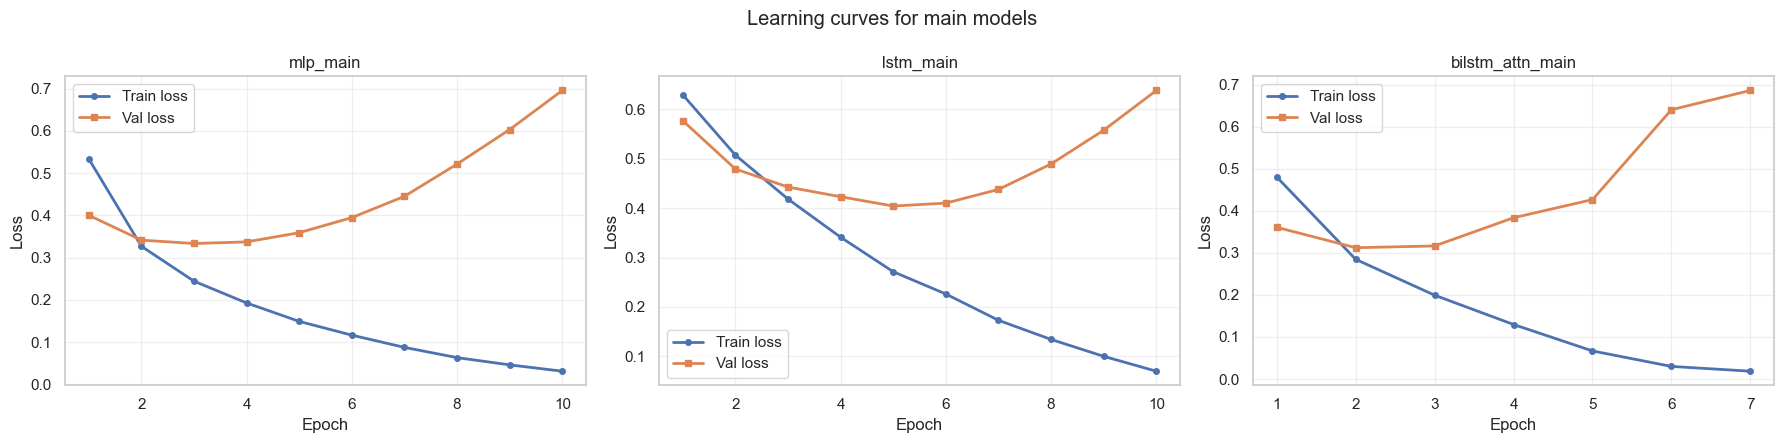

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=False)
for ax, exp_name in zip(axes, ['mlp_main', 'lstm_main', 'bilstm_attn_main']):
    metrics_path = exp_dir / exp_name / 'metrics.csv'
    df = pd.read_csv(metrics_path)
    ax.plot(df['epoch'], df['train_loss'], marker='o', linewidth=2, markersize=4, label='Train loss')
    ax.plot(df['epoch'], df['val_loss'], marker='s', linewidth=2, markersize=4, label='Val loss')
    ax.set_title(exp_name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle('Learning curves for main models')
fig.tight_layout()
fig.savefig(fig_dir / 'learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

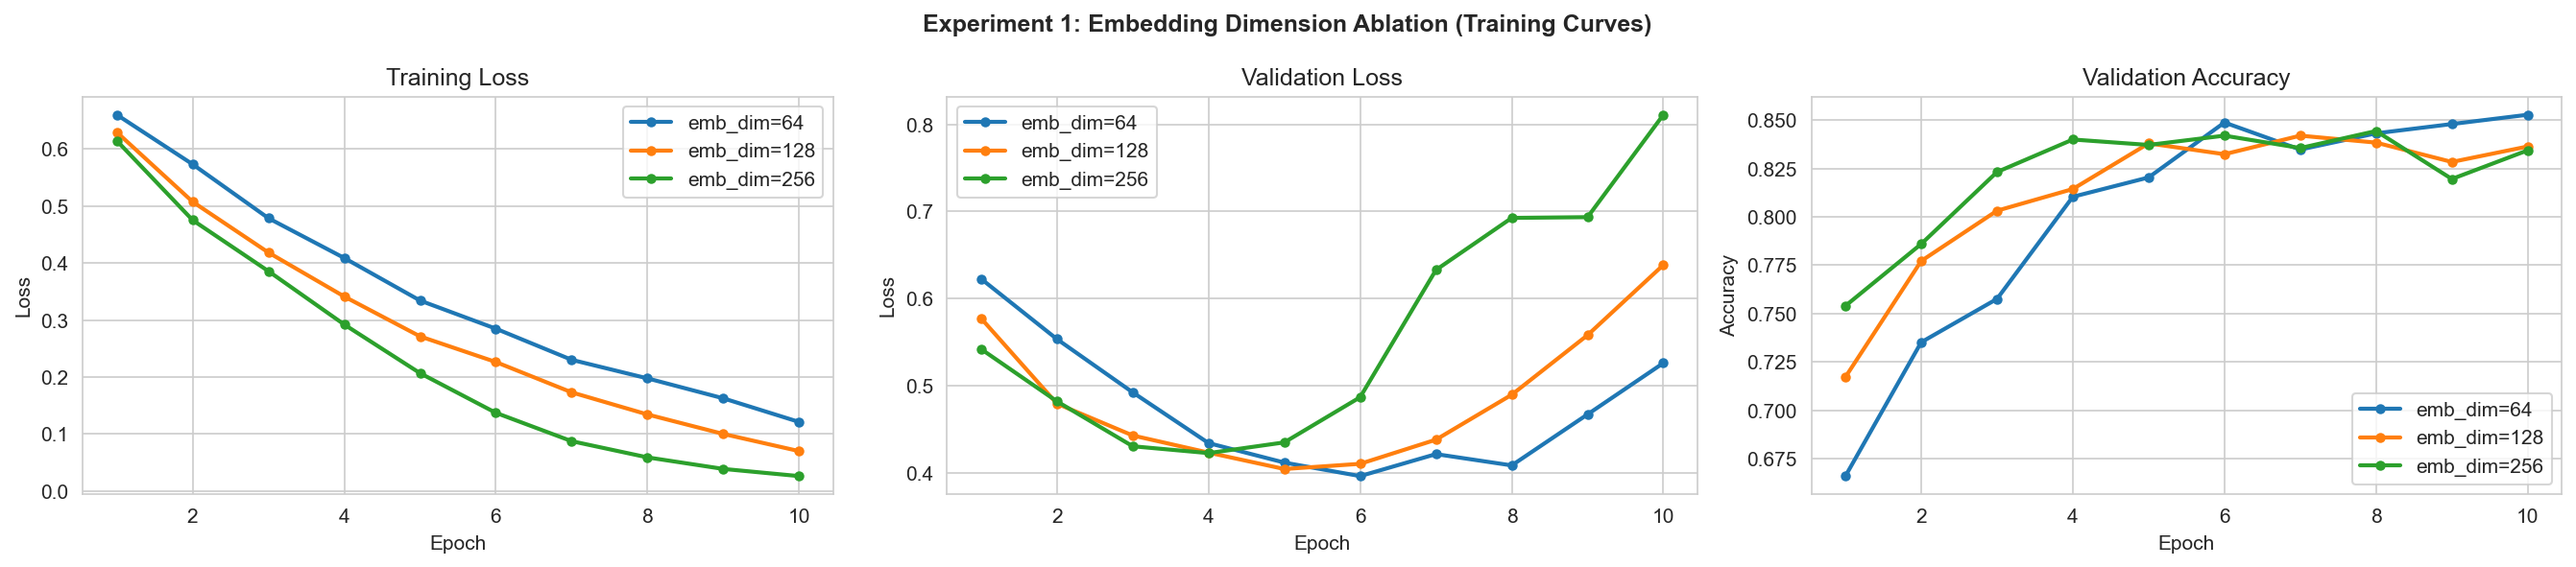

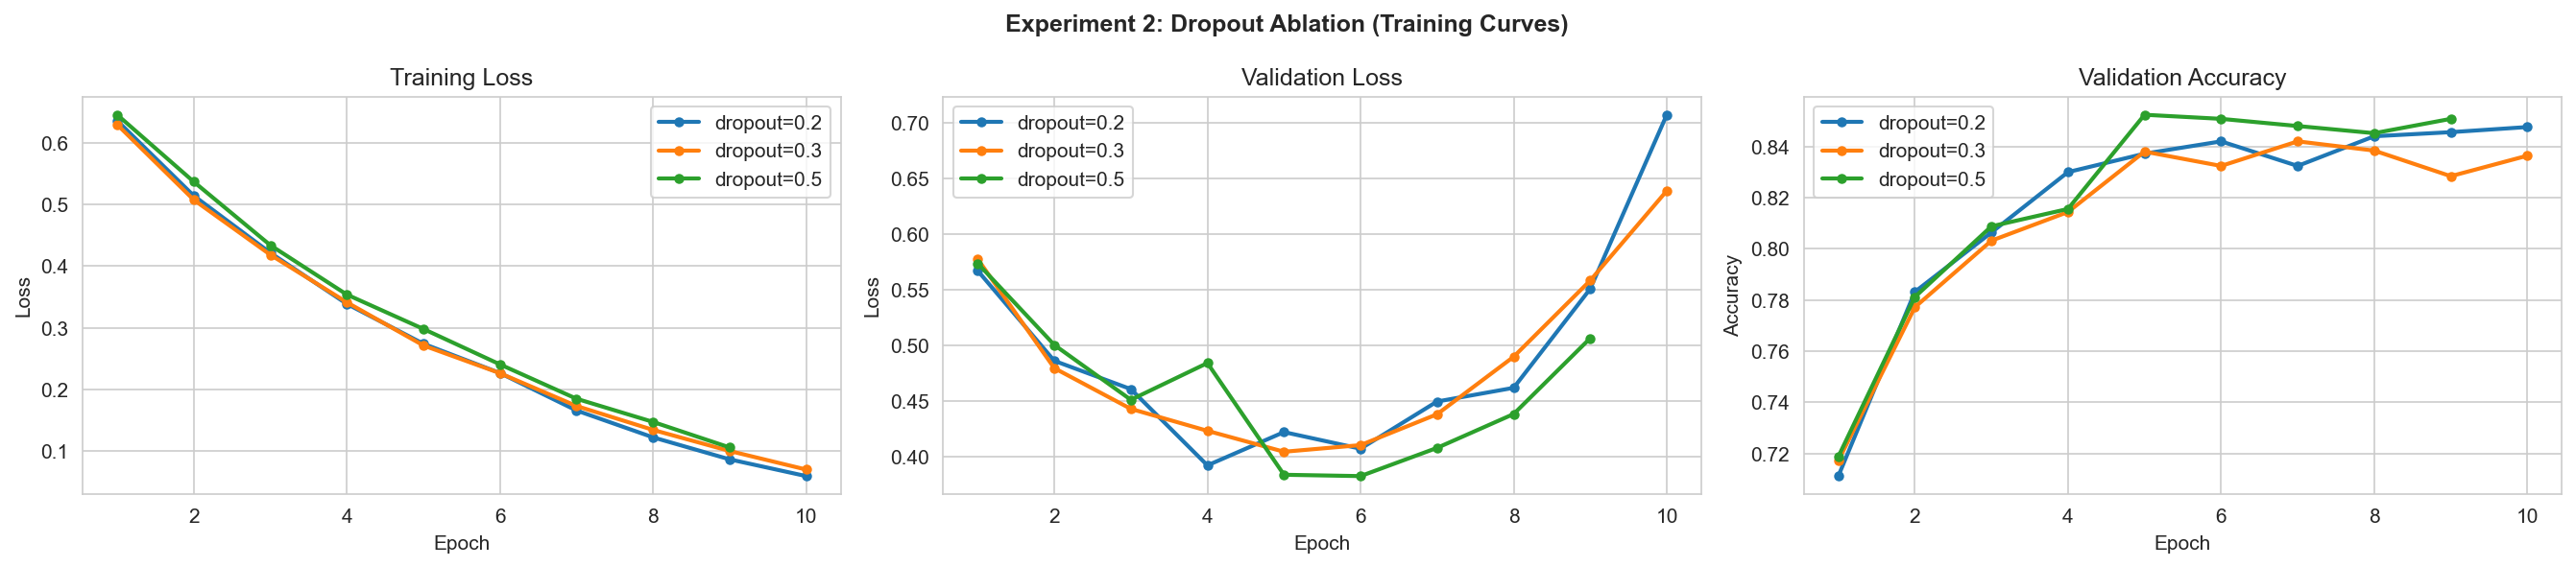

In [7]:
subprocess.run([
    'python', str(PROJECT_ROOT / 'scripts' / 'plot_ablation.py'),
    '--experiments', 'lstm_embed_dim_64', 'lstm_embed_dim_128', 'lstm_embed_dim_256',
    '--labels', 'emb_dim=64', 'emb_dim=128', 'emb_dim=256',
    '--title', 'Experiment 1: Embedding Dimension Ablation (Training Curves)',
    '--output', str(fig_dir / 'ablation_embed_dim.png')
], check=True, cwd=PROJECT_ROOT)
subprocess.run([
    'python', str(PROJECT_ROOT / 'scripts' / 'plot_ablation.py'),
    '--experiments', 'lstm_dropout_0.2', 'lstm_dropout_0.3', 'lstm_dropout_0.5',
    '--labels', 'dropout=0.2', 'dropout=0.3', 'dropout=0.5',
    '--title', 'Experiment 2: Dropout Ablation (Training Curves)',
    '--output', str(fig_dir / 'ablation_dropout.png')
], check=True, cwd=PROJECT_ROOT)

display(Image(filename=str(fig_dir / 'ablation_embed_dim.png')))
display(Image(filename=str(fig_dir / 'ablation_dropout.png')))

In [8]:
def _verdict(val_acc: float, gap: float) -> str:
    if val_acc < 0.7:
        return 'underfit'
    if gap < 0.02:
        return 'fit'
    if gap <= 0.05:
        return 'mild overfit'
    return 'strong overfit'

gap_rows = []
for exp_name in ['mlp_main', 'lstm_main', 'bilstm_attn_main']:
    df = pd.read_csv(exp_dir / exp_name / 'metrics.csv')
    best_idx = df['val_f1'].idxmax()
    row = df.loc[best_idx]
    gap = float(row['train_acc'] - row['val_accuracy'])
    gap_rows.append({
        'experiment': exp_name,
        'best_epoch': int(row['epoch']),
        'train_acc': float(row['train_acc']),
        'val_accuracy': float(row['val_accuracy']),
        'gap': gap,
        'verdict': _verdict(float(row['val_accuracy']), gap),
    })

gap_df = pd.DataFrame(gap_rows)
print(gap_df.to_string(index=False, formatters={'train_acc': '{:.4f}'.format, 'val_accuracy': '{:.4f}'.format, 'gap': '{:.4f}'.format}))
gap_df

      experiment  best_epoch train_acc val_accuracy    gap        verdict
        mlp_main           6    0.9618       0.8672 0.0946 strong overfit
       lstm_main           7    0.9366       0.8420 0.0946 strong overfit
bilstm_attn_main           3    0.9214       0.8788 0.0426   mild overfit


,experiment,best_epoch,train_acc,val_accuracy,gap,verdict
0,mlp_main,6,0.961822,0.8672,0.094622,strong overfit
1,lstm_main,7,0.936578,0.8420,0.094578,strong overfit
2,bilstm_attn_main,3,0.921378,0.8788,0.042578,mild overfit


## Summary

- The best overall model is the one with the highest test F1 among the three main runs.
- Increasing embedding dimension should improve performance up to a point, but larger embeddings also increase the parameter count.
- Dropout changes the balance between fitting and generalization, with intermediate values often performing best.
- The learning-curve and gap analysis help identify whether the main models are underfitting or overfitting.